In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


img = cv2.imread('img5.jfif')
if img is None:
    print('Image not found.')


img_rgb = cv2.cvtColor(
    img, cv2.COLOR_BGR2RGB
)
rows, cols, _ = img.shape


M_trans = np.float32([[1, 0, 50], [0, 1, 100]])
translated = cv2.warpAffine(img_rgb, M_trans, (cols, rows))


center = (cols // 2, rows // 2)
M_rot = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(img_rgb, M_rot, (cols, rows))

scaled = cv2.resize(
    img_rgb, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR
)

In [2]:
pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
pts2 = np.float32([[10, 100], [200, 50], [100, 250]])

M_affine = cv2.getAffineTransform(pts1, pts2)
affine_img = cv2.warpAffine(img, M_affine, (img.shape[1], img.shape[0]))

In [3]:
small = cv2.resize(img_rgb, (cols // 4, rows // 4))
inter_nearest = cv2.resize(
    small, (cols, rows), interpolation=cv2.INTER_NEAREST
)
inter_linear = cv2.resize(small, (cols, rows), interpolation=cv2.INTER_LINEAR)
inter_cubic = cv2.resize(small, (cols, rows), interpolation=cv2.INTER_CUBIC)
inter_lanczos = cv2.resize(small, (cols, rows), interpolation=cv2.INTER_LANCZOS4)

In [4]:
g_lower = cv2.pyrDown(img_rgb)
g_higher = cv2.pyrUp(
    g_lower, dstsize=(img_rgb.shape[1], img_rgb.shape[0])
)
laplacian_img = cv2.subtract(img_rgb, g_higher)

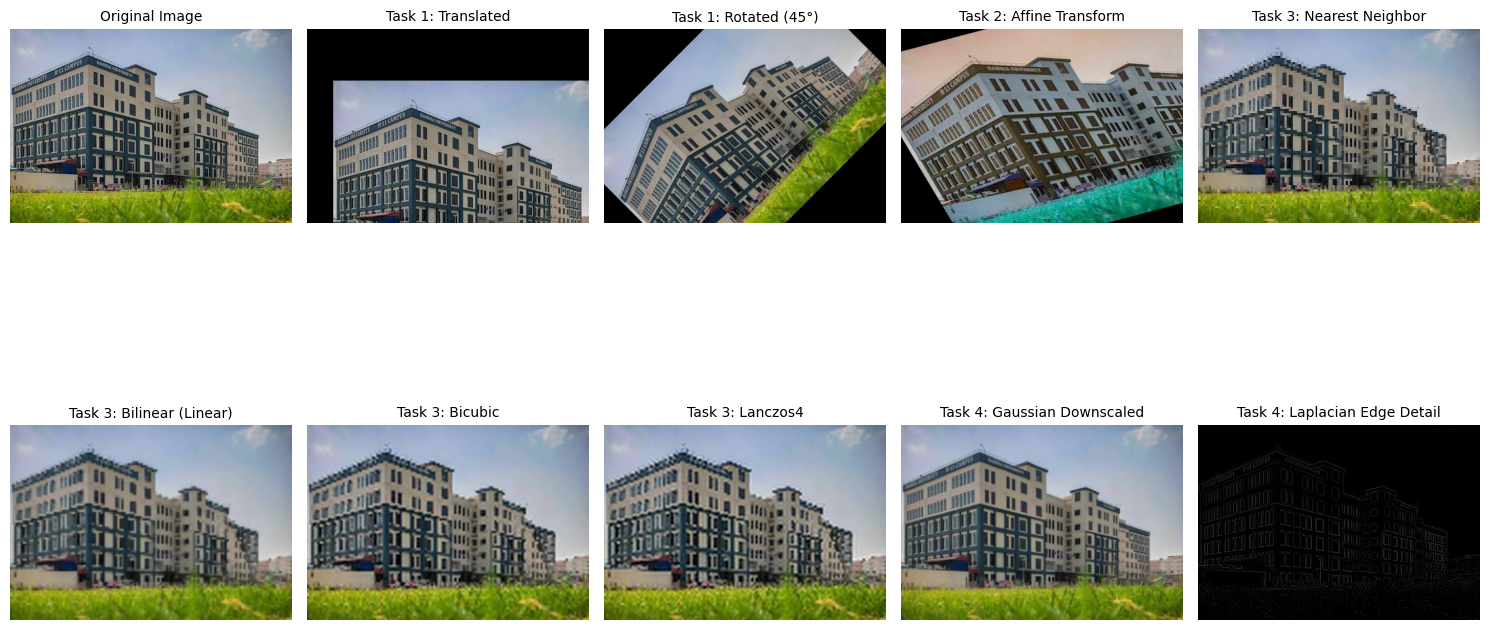

In [9]:
plt.figure(figsize=(15, 10))

tasks_to_plot = [
    (1, img_rgb, 'Original Image'),
    (2, translated, 'Task 1: Translated'),
    (3, rotated, 'Task 1: Rotated (45°)'),
    (4, affine_img, 'Task 2: Affine Transform'),
    (5, inter_nearest, 'Task 3: Nearest Neighbor'),
    (6, inter_linear, 'Task 3: Bilinear (Linear)'),
    (7, inter_cubic, 'Task 3: Bicubic'),
    (8, inter_lanczos, 'Task 3: Lanczos4'),
    (9, g_lower, 'Task 4: Gaussian Downscaled'),
    (10, laplacian_img, 'Task 4: Laplacian Edge Detail'),
]

for idx, img_to_show, title in tasks_to_plot:
  plt.subplot(2, 5, idx)

  if len(img_to_show.shape) == 2 or img_to_show.shape[2] == 1:
    plt.imshow(img_to_show, cmap='gray')
  else:
    plt.imshow(img_to_show)
  plt.title(title, fontsize=10)
  plt.axis('off')

plt.tight_layout()
plt.savefig('task_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

## Re-compiling Task 1: Composite of Geometric Transformations (Translation, Rotation, Scaling, and Shear)

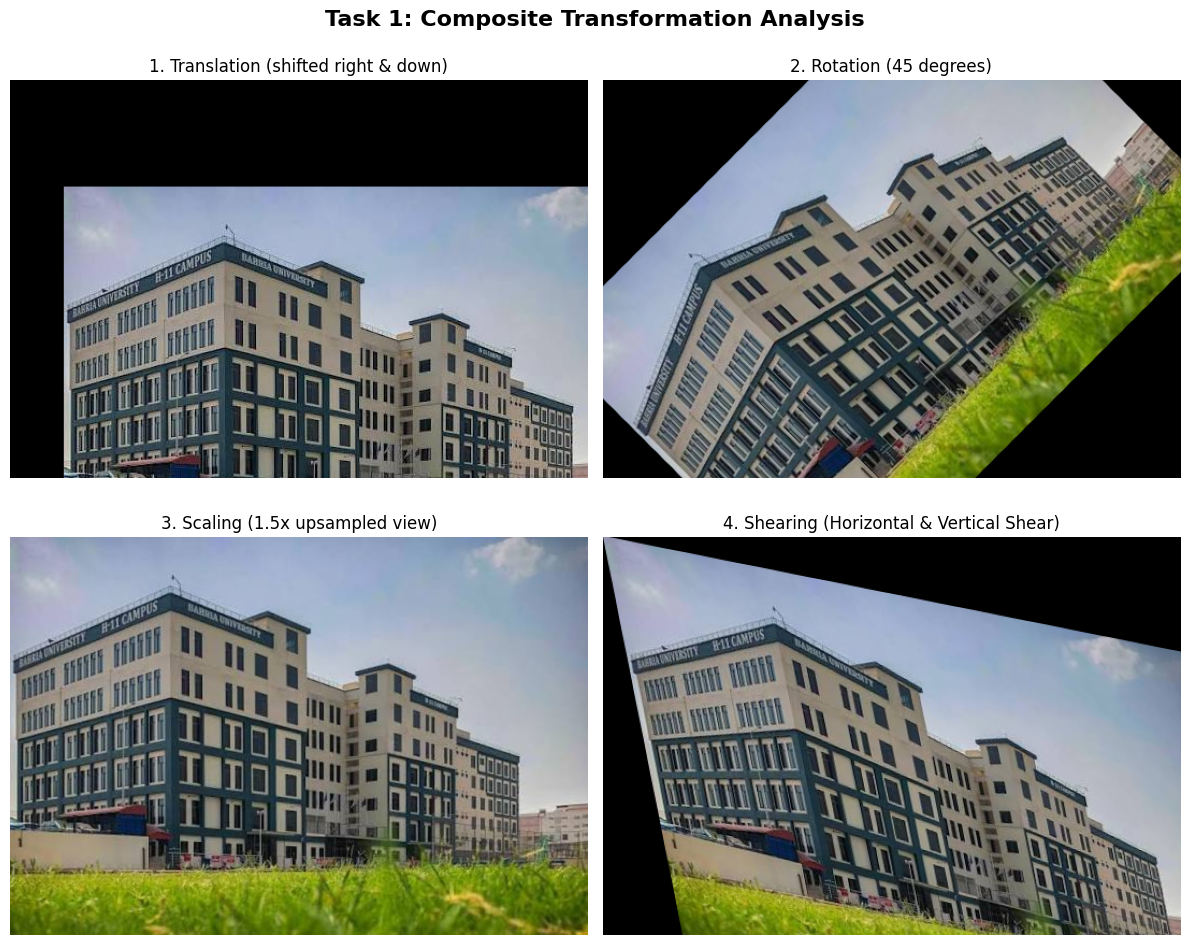

In [10]:
# Shear transformation matrix
M_shear = np.float32([[1, 0.2, 0], [0.2, 1, 0]])
sheared = cv2.warpAffine(img_rgb, M_shear, (cols, rows))

# Set up a clean 2x2 composite display of the transformed objects
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(translated)
axes[0, 0].set_title('1. Translation (shifted right & down)')
axes[0, 0].axis('off')

axes[0, 1].imshow(rotated)
axes[0, 1].set_title('2. Rotation (45 degrees)')
axes[0, 1].axis('off')

axes[1, 0].imshow(scaled)
axes[1, 0].set_title('3. Scaling (1.5x upsampled view)')
axes[1, 0].axis('off')

axes[1, 1].imshow(sheared)
axes[1, 1].set_title('4. Shearing (Horizontal & Vertical Shear)')
axes[1, 1].axis('off')

plt.suptitle('Task 1: Composite Transformation Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_composite.png', bbox_inches='tight', dpi=300)
plt.show()

## Re-compiling Task 2: Interpolation Comparison During Enlargement
To clearly observe interpolation differences, we zoom in on a small region (e.g., a window/edge) of the downscaled image and enlarge it.

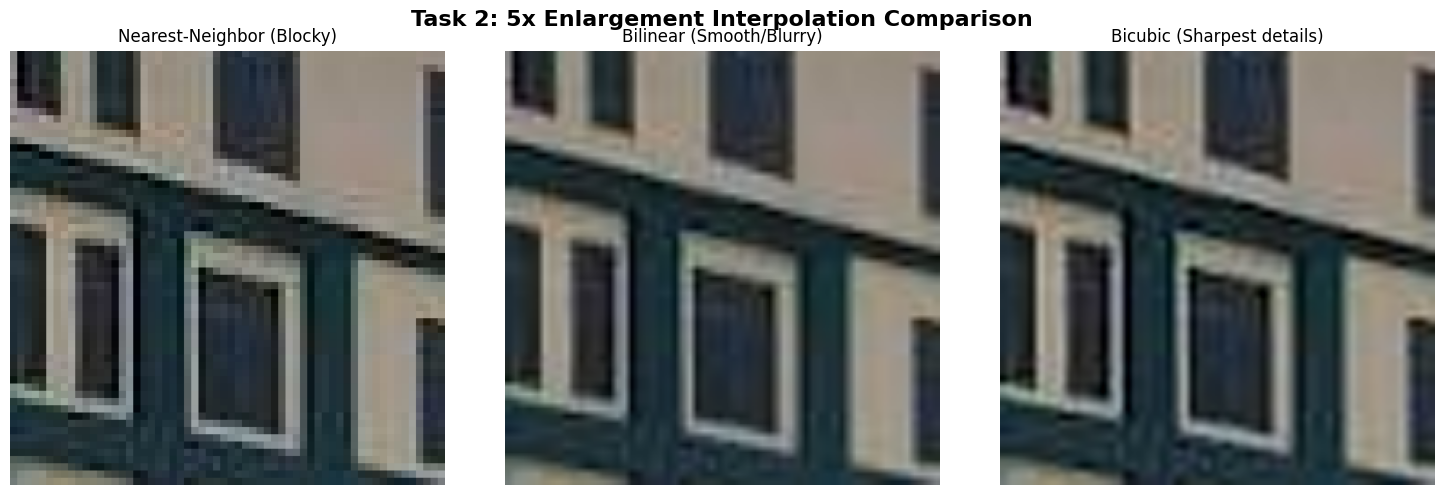

In [11]:
# Crop a small 60x60 patch representing high frequency details
patch = img_rgb[150:210, 200:260]

# Enlarge by 5x using different interpolation methods
zoom_nearest = cv2.resize(patch, None, fx=5, fy=5, interpolation=cv2.INTER_NEAREST)
zoom_bilinear = cv2.resize(patch, None, fx=5, fy=5, interpolation=cv2.INTER_LINEAR)
zoom_bicubic = cv2.resize(patch, None, fx=5, fy=5, interpolation=cv2.INTER_CUBIC)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(zoom_nearest)
axes[0].set_title('Nearest-Neighbor (Blocky)')
axes[0].axis('off')

axes[1].imshow(zoom_bilinear)
axes[1].set_title('Bilinear (Smooth/Blurry)')
axes[1].axis('off')

axes[2].imshow(zoom_bicubic)
axes[2].set_title('Bicubic (Sharpest details)')
axes[2].axis('off')

plt.suptitle('Task 2: 5x Enlargement Interpolation Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_interpolation_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

## Re-compiling Task 3: Four-Point Perspective Correction
We apply a perspective warp (Homography) to correct the perspective of the building facade.

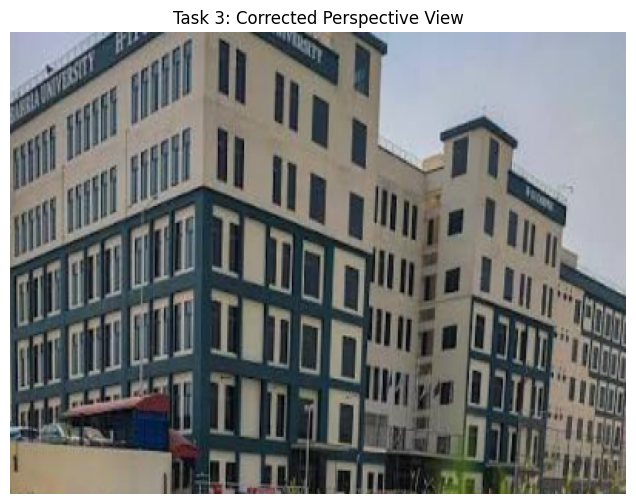

In [12]:
# Define four source corner points on the building facade
src_pts = np.float32([
    [10, 80],
    [450, 80],
    [480, 300],
    [5, 300]
])

# Define destination coordinates to warp into a straight front-on poster view
dst_pts = np.float32([
    [0, 0],
    [400, 0],
    [400, 300],
    [0, 300]
])

# Compute the Homography matrix and warp
M_perspective = cv2.getPerspectiveTransform(src_pts, dst_pts)
warped_document = cv2.warpPerspective(img_rgb, M_perspective, (400, 300))

plt.figure(figsize=(8, 6))
plt.imshow(warped_document)
plt.title('Task 3: Corrected Perspective View')
plt.axis('off')
plt.savefig('task3_perspective_correction.png', bbox_inches='tight', dpi=300)
plt.show()

### Task 5: Resolution Detail Analysis using Gaussian Pyramids
We will construct a multi-level Gaussian pyramid and visualize the absolute difference (details lost) between subsequent resolution levels.

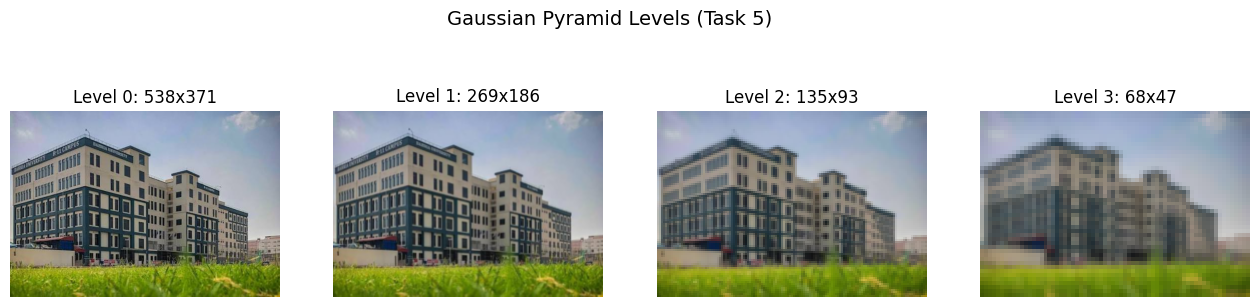

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Construct 4 levels of Gaussian Pyramid
G0 = img_rgb.copy()
G1 = cv2.pyrDown(G0)
G2 = cv2.pyrDown(G1)
G3 = cv2.pyrDown(G2)

# Visualize detail changes at different resolutions
plt.figure(figsize=(16, 4))
levels = [G0, G1, G2, G3]
for i, lvl in enumerate(levels):
    plt.subplot(1, 4, i + 1)
    plt.imshow(lvl)
    plt.title(f'Level {i}: {lvl.shape[1]}x{lvl.shape[0]}')
    plt.axis('off')
plt.suptitle('Gaussian Pyramid Levels (Task 5)', fontsize=14)
plt.show()

### Task 6: Direct Subsampling vs. Gaussian Pre-filtered Downsampling
Downsampling an image without filtering leads to aliasing (high frequencies mimicking low frequencies). We compare direct pixel decimation (slicing) against proper Gaussian-filtered downsampling (using `cv2.pyrDown` or Gaussian blur followed by decimation).

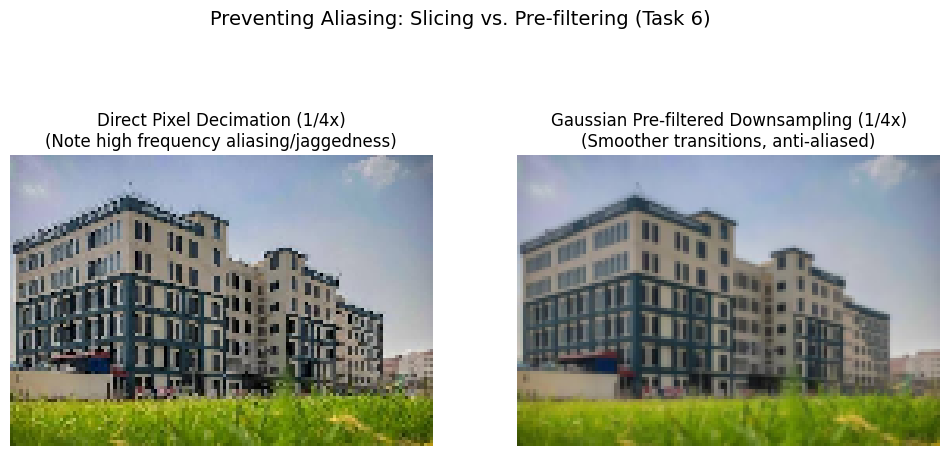

In [7]:
scale_factor = 4

# 1. Direct decimation (subsampling without filtering)
subsampled_direct = img_rgb[::scale_factor, ::scale_factor]

# 2. Proper downsampling with low-pass pre-filtering
# Apply a Gaussian blur matched to our downsampling rate, then slice
ksize = scale_factor * 2 + 1
filtered_blur = cv2.GaussianBlur(img_rgb, (ksize, ksize), 0)
subsampled_filtered = filtered_blur[::scale_factor, ::scale_factor]

# Visualize the comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(subsampled_direct)
plt.title(f'Direct Pixel Decimation (1/{scale_factor}x)\n(Note high frequency aliasing/jaggedness)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(subsampled_filtered)
plt.title(f'Gaussian Pre-filtered Downsampling (1/{scale_factor}x)\n(Smoother transitions, anti-aliased)')
plt.axis('off')

plt.suptitle('Preventing Aliasing: Slicing vs. Pre-filtering (Task 6)', fontsize=14)
plt.show()

### Task 7: Upscaling Quality and Artifact Comparison
We will take a heavily downsampled version of the asset and upscale it using different interpolation kernels to observe blocky artifacts, blurriness, and ringing.

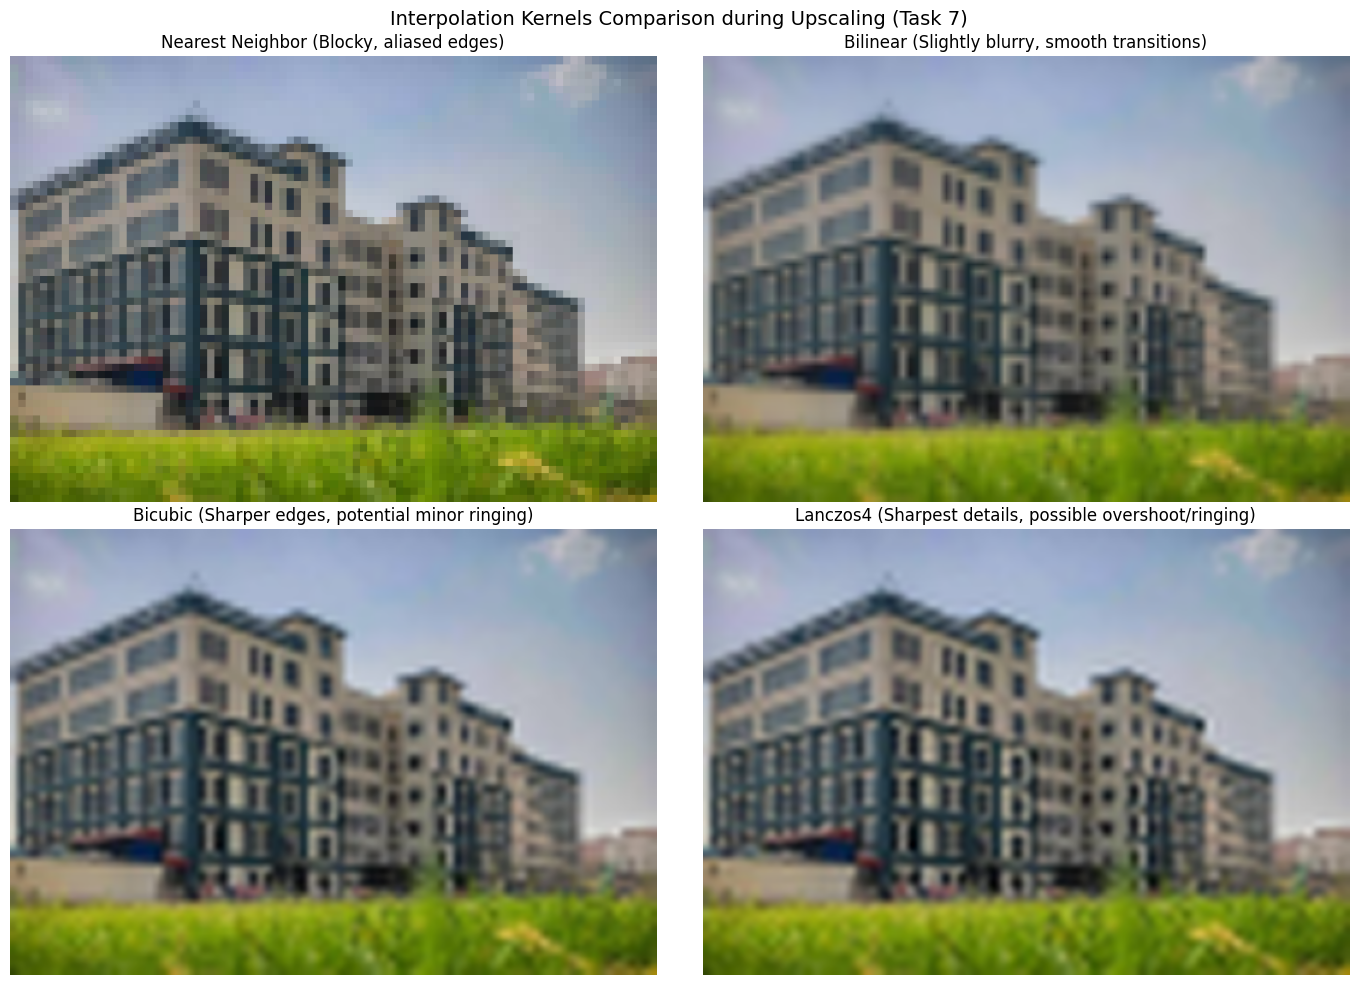

In [8]:
# Start with a low-resolution asset (1/6th of original size)
low_res = cv2.resize(img_rgb, (cols // 6, rows // 6), interpolation=cv2.INTER_AREA)
h, w, _ = img_rgb.shape

# Upscale back to original resolution using different techniques
up_nearest = cv2.resize(low_res, (w, h), interpolation=cv2.INTER_NEAREST)
up_bilinear = cv2.resize(low_res, (w, h), interpolation=cv2.INTER_LINEAR)
up_bicubic = cv2.resize(low_res, (w, h), interpolation=cv2.INTER_CUBIC)
up_lanczos = cv2.resize(low_res, (w, h), interpolation=cv2.INTER_LANCZOS4)

# Plotting results for visual inspection
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
methods = [
    (up_nearest, 'Nearest Neighbor (Blocky, aliased edges)'),
    (up_bilinear, 'Bilinear (Slightly blurry, smooth transitions)'),
    (up_bicubic, 'Bicubic (Sharper edges, potential minor ringing)'),
    (up_lanczos, 'Lanczos4 (Sharpest details, possible overshoot/ringing)')
]

for idx, (upscaled_img, title) in enumerate(methods):
    ax = axes[idx // 2, idx % 2]
    ax.imshow(upscaled_img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.suptitle('Interpolation Kernels Comparison during Upscaling (Task 7)', fontsize=14)
plt.tight_layout()
plt.show()